# Baseline notebook

## Imports

In [21]:
from tqdm import tqdm

import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import plotly.express as px
import matplotlib.pyplot as plt
from skimage.filters import rank
from scipy import ndimage as ndi
from skimage.filters import sobel
from skimage.morphology import disk
from skimage.segmentation import watershed, felzenszwalb

# Handling the data

In [4]:
# Load the train labels
# Note the transpose!
labels_train = pd.read_csv("dataset/raw/y-train.csv", index_col=0).T

In [5]:
# Here is a function to load the data
def load_dataset(dataset_dir):
    dataset_list = []
    # Note: It's very important to load the images in the correct numerical order!
    for image_file in list(sorted(Path(dataset_dir).glob("*.png"), key=lambda filename: int(filename.name.rstrip(".png")))):
        dataset_list.append(cv2.imread(str(image_file), cv2.IMREAD_GRAYSCALE))
    return np.stack(dataset_list, axis=0)

In [6]:
# Load the train and test sets
# If you've put the shortcut directly in your drive, this should work out of the box
# Else, edit the path
data_dir = Path("./dataset/raw")
data_train = load_dataset(data_dir / "x-train")
data_test = load_dataset(data_dir / "x-test")

In [7]:
data_test

array([[[12, 12, 13, ..., 14, 14, 14],
        [12, 12, 12, ..., 15, 15, 15],
        [12, 12, 13, ..., 15, 15, 15],
        ...,
        [12, 12, 13, ..., 12, 13, 13],
        [12, 12, 12, ..., 13, 12, 12],
        [12, 12, 12, ..., 12, 13, 13]],

       [[12, 12, 12, ..., 14, 14, 14],
        [12, 12, 12, ..., 15, 15, 15],
        [12, 12, 12, ..., 15, 15, 15],
        ...,
        [12, 12, 12, ..., 12, 12, 12],
        [12, 12, 12, ..., 12, 12, 12],
        [12, 12, 12, ..., 12, 12, 12]],

       [[13, 13, 13, ..., 15, 15, 15],
        [13, 13, 13, ..., 15, 15, 15],
        [13, 13, 13, ..., 15, 15, 15],
        ...,
        [13, 13, 13, ..., 13, 13, 13],
        [13, 13, 13, ..., 13, 13, 13],
        [13, 13, 13, ..., 13, 13, 13]],

       ...,

       [[16, 16, 16, ..., 16, 16, 16],
        [16, 16, 16, ..., 16, 16, 16],
        [16, 16, 16, ..., 16, 16, 16],
        ...,
        [16, 16, 16, ..., 16, 16, 16],
        [16, 16, 16, ..., 16, 16, 16],
        [16, 16, 16, ..., 16, 16

In [8]:
# The train data is a numpy array of 1000 images of 512*512
print(f"X_train shape: {data_train.shape}")
# The train label is a dataframe of 1000 rows with 262144 (=512x512) columns
print(f"Y_train shape: {labels_train.shape}")

X_train shape: (2000, 256, 256)
Y_train shape: (2000, 65536)


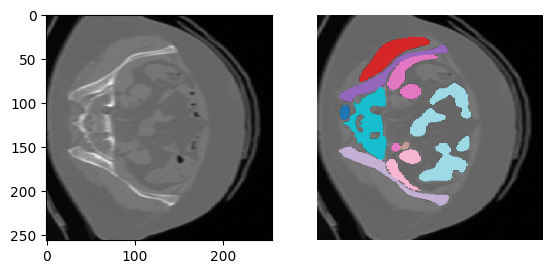

In [9]:
# Let's display some data
# Here is a function to display side by side a slide and a segmented mask
def plot_slice_seg(slice_image, seg):
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(slice_image, cmap="gray")
    axes[1].imshow(slice_image, cmap="gray")
    seg_masked = np.ma.masked_where(seg.reshape((256,256)) == 0, (seg.reshape((256,256))))
    axes[1].imshow(seg_masked, cmap="tab20")
    plt.axis("off")

# Let's try it on a slide and ites segmentation mask
# Note: we have to reshape the rows of the dataframe into a 256*256 matrix
plot_slice_seg(data_train[0], labels_train.iloc[0].values.reshape((256,256)))

# Let's compute a baseline

In [10]:
# Let's take a very basic watershed baseline
def compute_baseline_one_sample(data_slice):
    edges = sobel(data_slice)
    denoised = rank.median(data_slice, disk(2))
    markers = rank.gradient(denoised, disk(5)) < 20
    markers = ndi.label(markers)[0]
    label_predicted = watershed(edges, markers=markers, compactness=0.0001)
    return label_predicted

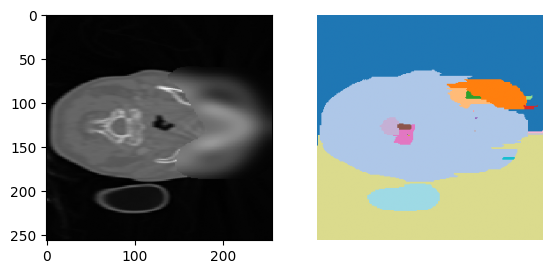

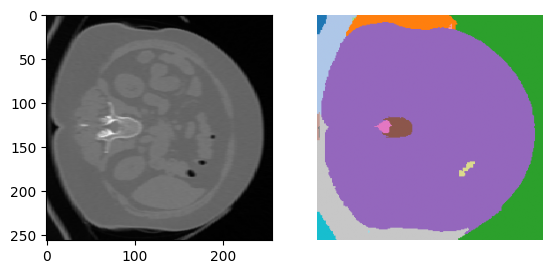

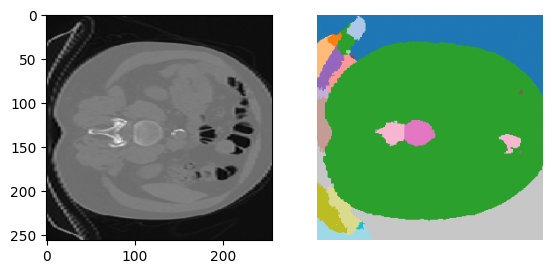

In [11]:
# Let's display the results
# Not too bad!
plot_slice_seg(data_train[2], compute_baseline_one_sample(data_train[2]))
plot_slice_seg(data_train[1], compute_baseline_one_sample(data_train[1]))
plot_slice_seg(data_train[200], compute_baseline_one_sample(data_train[200]))

## Let's measure its performances

In [12]:
# Compute the baseline on a whole dataset
def compute_baseline(dataset: np.array):
    labels_predicted_list = []
    for data_index in tqdm(range(len(dataset))):
        data_slice = dataset[data_index]
        label_predicted = compute_baseline_one_sample(data_slice)
        labels_predicted_list.append(label_predicted)
    return pd.DataFrame(np.stack(labels_predicted_list, axis=0).reshape((len(labels_predicted_list), -1)))

In [13]:
# Let's create a validation set first: the 200 first images of the train set
data_val = data_train[:200]
labels_val = labels_train.iloc[:200]

In [14]:
# Compute baseline on a few train data
labels_val_predicted_baseline = compute_baseline(data_val)

100%|██████████| 200/200 [00:07<00:00, 28.44it/s]


In [15]:
NUM_CLASSES = 54 # 55 classes in total, but the first one is the background


def dice_image(prediction, ground_truth):
    intersection = np.sum(prediction * ground_truth)
    if np.sum(prediction) == 0 and np.sum(ground_truth) == 0:
        return np.nan
    return 2 * intersection / (np.sum(prediction) + np.sum(ground_truth))


def dice_multiclass(prediction, ground_truth):
    dices = []
    for i in range(1, NUM_CLASSES + 1): # skip background
        dices.append(dice_image(prediction == i, ground_truth == i))
    return np.array(dices)

def dice_pandas(y_true_df: pd.DataFrame, y_pred_df: pd.DataFrame) -> float:
    """Compute the dice score for each sample in the dataset and then average it"""
    y_pred_df = y_pred_df.T
    y_true_df = y_true_df.T
    individual_dice = []
    for row_index in range(y_true_df.values.shape[0]):
        dices = dice_multiclass(y_true_df.values[row_index].ravel(), y_pred_df.values[row_index].ravel())
        individual_dice.append(dices)

    final = np.stack(individual_dice)
    # First, average over images for each class
    # Then, average over classes
    cls_dices = np.nanmean(final, axis=0)
    return float(np.nanmean(cls_dices))


In [16]:
# Compute the metric on the validation set
dice_pandas(labels_val, labels_val_predicted_baseline)
# We get => (0.0011196021617737601); Not so bad, but room for improvements!
# Let's see if you can do better!

0.0011589275715720602

In [17]:
labels_val_predicted_baseline.shape

(200, 65536)

In [18]:
test_preds = compute_baseline(data_test)
test_preds

  1%|          | 4/500 [00:00<00:16, 30.09it/s]

100%|██████████| 500/500 [00:17<00:00, 28.04it/s]


,0,1,2,3,4,5,6,7,8,9,...,65526,65527,65528,65529,65530,65531,65532,65533,65534,65535
0,1,1,1,1,1,1,1,1,1,1,...,3,3,3,3,3,3,3,3,3,3
1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2,1,1,1,1,1,1,1,1,1,1,...,3,3,3,3,3,3,3,3,3,3
3,1,1,1,1,1,1,1,1,1,1,...,8,8,8,8,8,8,8,8,8,8
4,1,1,1,1,1,1,1,1,1,1,...,4,4,4,4,4,4,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1,1,1,1,1,1,1,1,1,1,...,3,3,3,3,3,3,3,3,3,3
496,1,1,1,1,1,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
497,1,1,1,1,1,1,1,1,1,1,...,4,4,4,4,4,4,4,4,4,4
498,1,1,1,1,1,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2


In [19]:
labels_val.index[0]

'0.png'

In [22]:
first_label = labels_val.iloc[0].values.reshape(256, 256)
px.imshow(first_label)

In [23]:
test_preds.max().max()

np.int32(280)

In [24]:
import plotly.express as px
first_test_pred = (
    test_preds
    .iloc[0]
    .values
    .reshape(256, 256)
)
px.imshow(first_test_pred)

In [25]:
test_preds.columns = [f"Pixel {idx}" for idx in range(test_preds.shape[1])]
test_preds.index = [f"{idx}.png" for idx in range(test_preds.shape[0])]
test_preds

,Pixel 0,Pixel 1,Pixel 2,Pixel 3,Pixel 4,Pixel 5,Pixel 6,Pixel 7,Pixel 8,Pixel 9,...,Pixel 65526,Pixel 65527,Pixel 65528,Pixel 65529,Pixel 65530,Pixel 65531,Pixel 65532,Pixel 65533,Pixel 65534,Pixel 65535
0.png,1,1,1,1,1,1,1,1,1,1,...,3,3,3,3,3,3,3,3,3,3
1.png,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2.png,1,1,1,1,1,1,1,1,1,1,...,3,3,3,3,3,3,3,3,3,3
3.png,1,1,1,1,1,1,1,1,1,1,...,8,8,8,8,8,8,8,8,8,8
4.png,1,1,1,1,1,1,1,1,1,1,...,4,4,4,4,4,4,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495.png,1,1,1,1,1,1,1,1,1,1,...,3,3,3,3,3,3,3,3,3,3
496.png,1,1,1,1,1,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
497.png,1,1,1,1,1,1,1,1,1,1,...,4,4,4,4,4,4,4,4,4,4
498.png,1,1,1,1,1,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2


In [ ]:
(
    test_preds
    .sub(1)
    .clip(upper=255)
    .T
    .to_csv("submission.csv")
)

In [ ]:
!head submission.csv
!tail submission.csv

,0.png,1.png,2.png,3.png,4.png,5.png,6.png,7.png,8.png,9.png,10.png,11.png,12.png,13.png,14.png,15.png,16.png,17.png,18.png,19.png,20.png,21.png,22.png,23.png,24.png,25.png,26.png,27.png,28.png,29.png,30.png,31.png,32.png,33.png,34.png,35.png,36.png,37.png,38.png,39.png,40.png,41.png,42.png,43.png,44.png,45.png,46.png,47.png,48.png,49.png,50.png,51.png,52.png,53.png,54.png,55.png,56.png,57.png,58.png,59.png,60.png,61.png,62.png,63.png,64.png,65.png,66.png,67.png,68.png,69.png,70.png,71.png,72.png,73.png,74.png,75.png,76.png,77.png,78.png,79.png,80.png,81.png,82.png,83.png,84.png,85.png,86.png,87.png,88.png,89.png,90.png,91.png,92.png,93.png,94.png,95.png,96.png,97.png,98.png,99.png,100.png,101.png,102.png,103.png,104.png,105.png,106.png,107.png,108.png,109.png,110.png,111.png,112.png,113.png,114.png,115.png,116.png,117.png,118.png,119.png,120.png,121.png,122.png,123.png,124.png,125.png,126.png,127.png,128.png,129.png,130.png,131.png,132.png,133.png,134.png,135.png,136.png,137.png,138.p